In [1]:
#import mortality rate of under 5, for all country
#Data Preparation
!pip install pycountry
import pandas as pd
import pycountry

url = "https://ourworldindata.org/grapher/under-5-mortality-rate-sdgs.csv?v=1&csvType=full&useColumnShortNames=true"
mortality_under_5 = pd.read_csv(url, storage_options={'User-Agent': 'Our World In Data data fetch/1.0'})
print(mortality_under_5.head())

#The mortality rate was collected in per 100, the rate was coverted to per 1000 by multipying per 100 to work with the general recorded rate of per 1000
mortality_under_5["per_1000"] = mortality_under_5["observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births"] * 10
mortality_under_5.head()

#The name of countries and their ISO code in existence
countries = []
for c in pycountry.countries:
    countries.append({
        'country_name': c.name,
        'iso_alpha3': c.alpha_3
    })

iso_data = pd.DataFrame(countries).sort_values('country_name').reset_index(drop=True)
print(iso_data.head())

#Rename the column that contains the code for each country of iso data, so it can be merge with under_5 mortality data
iso_data = iso_data.rename(columns={'iso_alpha3': 'code', "country_name":"entity"})
iso_data.head()

#Merge under_5_mertality data on the left with iso_data so as to filter the data to all country,
#because the under_5_mortality data as some world back indicator in between which does not belong to any country
mortality_under_5_new = pd.merge(mortality_under_5, iso_data, on=['code', "entity"], how='left')
mortality_under_5_new.head()

#Validating my new data
print(mortality_under_5.shape)
print(mortality_under_5_new.shape)

#Then merge isn't the proper method, i will try filter method
mortality_under_5_new_2 = mortality_under_5[mortality_under_5["code"].isin(iso_data["code"])]
print(mortality_under_5_new_2.shape)
mortality_under_5_new_2.head()

#validating if we have all countries in the list
print(mortality_under_5_new_2["code"].unique())
unique_coutries = mortality_under_5_new_2["code"].unique()
print(len(unique_coutries))

#Importing data for income category for each country
import requests
import pandas as pd

# Pull country metadata including income classification
url = "https://api.worldbank.org/v2/country?format=json&per_page=300"
response = requests.get(url)
data = response.json()[1]
# index 0 is pagination info, index 1 is the actual data

# Flatten the nested structure
income_level = pd.DataFrame([
    {
        "Code": c["id"],
        "country_name": c["name"],
        "income_group": c["incomeLevel"]["value"],
        "region": c["region"]["value"]
    }
    for c in data
])

# Drop non-country aggregates (World Bank includes regional groupings here too)
income_level = income_level[income_level["income_group"] != "Aggregates"]

print(income_level["income_group"].unique())
income_level.head()

#Now i have my income level data, so i will like extract two columns from it to the mortarlity data
mortality_under_5_new_2["income_level"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Code')['income_group'])
mortality_under_5_new_2["regions"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Code')['region'])
print(mortality_under_5_new_2.head())
print(mortality_under_5_new_2["income_level"].unique())
print(mortality_under_5_new_2["regions"].unique())


#I waant to drop missing value in the data
mort_und_5_new_2_dropna = mortality_under_5_new_2.dropna()
print(mort_und_5_new_2_dropna.shape)
print(mort_und_5_new_2_dropna.isna().sum())

#Since my interest is working on years from year 2000 to later year.
mort_und_5_new_2_dropna_2000 = mort_und_5_new_2_dropna[mort_und_5_new_2_dropna["year"] >= 2000]
print(mort_und_5_new_2_dropna_2000.shape)

#validating which countries have dropped since i applied dropping missing valuea nd also
#applied filtered for years above 2000
print(mort_und_5_new_2_dropna_2000["code"].unique())
unique_coutries_2 = mort_und_5_new_2_dropna_2000["code"].unique()
print(len(unique_coutries_2))

# Rename data
mortality_under_5 = mort_und_5_new_2_dropna_2000
print(mortality_under_5.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 61.9 MB/s eta 0:00:00
        entity code  year  \
0  Afghanistan  AFG  1957   
1  Afghanistan  AFG  1958   
2  Afghanistan  AFG  1959   
3  Afghanistan  AFG  1960   
4  Afghanistan  AFG  1961   

   observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births  
0                                          36.819660                                                                                
1                                          36.206852                                                                                
2                                          35.644524                                                                                
3                                          35.055080                                                                                
4                                          34.519325                               

/tmp/ipykernel_475/582659671.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortality_under_5_new_2["income_level"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Code')['income_group'])
/tmp/ipykernel_475/582659671.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortality_under_5_new_2["regions"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Code'

In [3]:
#Rate of change in mortality rate from 2000 to 2024 for all country
# Step 1: Get first year (2000) and latest year values, pivoted side by side
first_year = mortality_under_5['year'].min()
last_year = mortality_under_5['year'].max()

pivot = mortality_under_5[mortality_under_5['year'].isin([first_year, last_year])].pivot(
    index=['entity', 'code'],
    columns='year',
    values='per_1000'
).reset_index()

# Step 2: Rename the pivoted year columns to match what the disparity code expects
# removes the 'year' label pandas adds to columns
import numpy as np
pivot.columns.name = None
pivot = pivot.rename(columns={first_year: 'rate_2000', last_year: 'rate_latest'})

# Step 3: Calculate absolute and percentage change
change = pivot['rate_latest'] - pivot['rate_2000']
pivot['absolute_change'] = np.abs(change)
pivot['pct_change'] = (pivot['absolute_change'] / pivot['rate_2000']) * 100

# Step 4: Drop any countries missing either year's data (can't compute change without both)
change = pivot.dropna(subset=['rate_2000', 'rate_latest'])

print(change.shape)
print(change.head())

(195, 6)
        entity code   rate_2000  rate_latest  absolute_change  pct_change
0  Afghanistan  AFG  131.707240    53.032020        78.675220   59.734924
1      Albania  ALB   26.968840     9.227080        17.741760   65.786143
2      Algeria  DZA   41.693606    21.640280        20.053326   48.096886
3      Andorra  AND    7.572376     2.507134         5.065242   66.891053
4       Angola  AGO  184.987580    48.999667       135.987913   73.511915


In [ ]:
#change.to_csv("/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 4/change.csv", index=False)

In [4]:
#Checking regional gap
current = mortality_under_5[mortality_under_5["year"] == 2024]
regional_gap = current.groupby("regions")["per_1000"].agg(["mean", "min", "max"])
regional_gap["gap"] = regional_gap["max"] - regional_gap["min"]
regional_gap = regional_gap.sort_values("gap", ascending=False)

print("Regional disparity (widest gap first):")
print(regional_gap)

Regional disparity (widest gap first):
                                                        mean        min  \
regions                                                                   
Sub-Saharan Africa                                 56.770046  11.139345   
Middle East, North Africa, Afghanistan & Pakistan  19.566879   3.339631   
East Asia & Pacific                                18.472211   2.433754   
Latin America & Caribbean                          15.866249   4.652511   
Europe & Central Asia                               6.442284   1.259518   
South Asia                                         18.446682   5.438741   
North America                                       5.949694   5.426926   

                                                          max         gap  
regions                                                                    
Sub-Saharan Africa                                 115.649430  104.510085  
Middle East, North Africa, Afghanistan & Pakistan   55.95

In [5]:
#income gap
income_gap = current.groupby("income_level")["per_1000"].agg(["mean", "min", "max"])
income_gap["gap"] = income_gap["max"] - income_gap["min"]
income_gap = income_gap.sort_values("mean", ascending=False)

print("Mortality by income group:")
print(income_gap)

# The headline number: how many times higher is low-income mortality than high-income?
ratio = income_gap.loc["Low income", "mean"] / income_gap.loc["High income", "mean"]
print(f"\nLow-income countries have {ratio:.1f}x the mortality rate of high-income countries")

Mortality by income group:
                          mean        min         max         gap
income_level                                                     
Low income           63.618333  16.665504  110.720350   94.054846
Lower middle income  38.302445  11.239390  115.649430  104.410040
Upper middle income  16.207600   2.331336   67.969017   65.637681
High income           6.229344   1.259518   25.209760   23.950242

Low-income countries have 10.2x the mortality rate of high-income countries


In [6]:
#Fastest improver by income
fastest_improvers = pivot.sort_values('pct_change', ascending=False).head(10)
print(fastest_improvers)

improvers_by_income = fastest_improvers.merge(
    mortality_under_5[["code", "income_level"]], on="code", how="left"
)["income_level"].value_counts()

print("Income group breakdown of top 10 fastest improvers:")
print(improvers_by_income)

                    entity code   rate_2000  rate_latest  absolute_change  \
104               Maldives  MDV   39.482270     5.438741        34.043529   
36                   China  CHN   36.639075     5.723935        30.915140   
49                Dominica  DMA   19.370811    35.658462        16.287651   
150  Sao Tome and Principe  STP   82.167210    13.554487        68.612723   
127            North Korea  PRK  100.234640    16.665504        83.569136   
115             Montenegro  MNE   14.203769     2.383296        11.820473   
94                  Latvia  LVA   14.298372     2.500961        11.797411   
29                Cambodia  KHM  105.178950    18.410044        86.768906   
128        North Macedonia  MKD   16.006331     2.803139        13.203192   
15                 Belarus  BLR   12.761927     2.331336        10.430591   

     pct_change  
104   86.224852  
36    84.377512  
49    84.083475  
150   83.503776  
127   83.373508  
115   83.220677  
94    82.508768  
29    82

In [7]:
#fatest improve by region
improvers_by_region = fastest_improvers.merge(
    mortality_under_5[["code", "regions"]], left_on="code", right_on="code", how="left"
)["regions"].value_counts()

print("Region breakdown of top 10 fastest improvers:")
print(improvers_by_region)

Region breakdown of top 10 fastest improvers:
regions
Europe & Central Asia         100
East Asia & Pacific            75
South Asia                     25
Latin America & Caribbean      25
Sub-Saharan Africa             25
Name: count, dtype: int64


In [8]:
print(mortality_under_5["regions"].unique())

['Middle East, North Africa, Afghanistan & Pakistan'
 'Europe & Central Asia' 'Sub-Saharan Africa '
 'Latin America & Caribbean ' 'East Asia & Pacific' 'South Asia'
 'North America']


In [9]:
print(current.columns)

Index(['entity', 'code', 'year',
       'observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births',
       'per_1000', 'income_level', 'regions'],
      dtype='object')


                                             regions  avg_under5_mr
0                                      North America       5.949694
1                              Europe & Central Asia       6.442284
2                         Latin America & Caribbean       15.866249
3                                         South Asia      18.446682
4                                East Asia & Pacific      18.472211
5  Middle East, North Africa, Afghanistan & Pakistan      19.566879
6                                Sub-Saharan Africa       56.770046


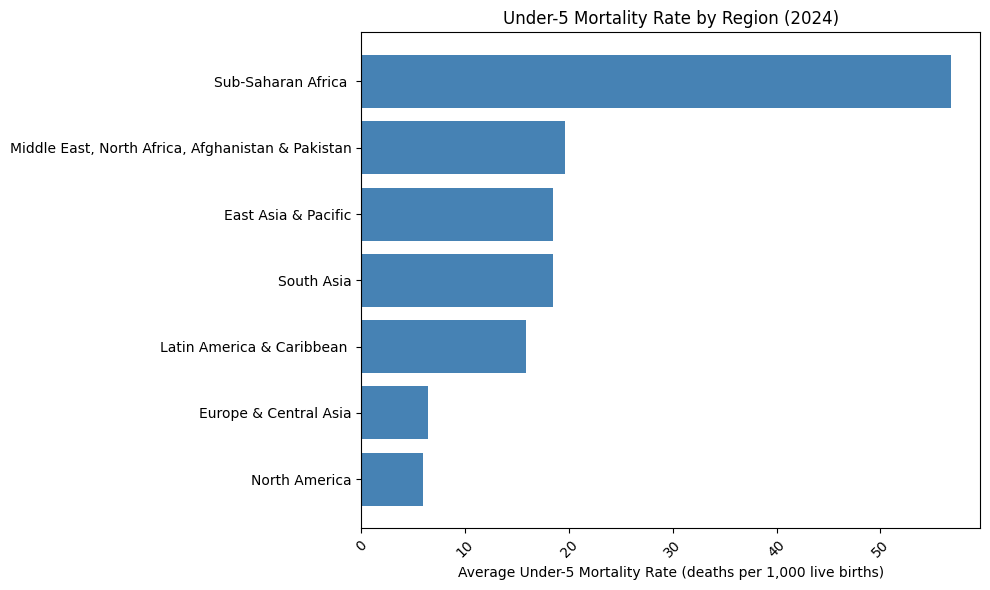

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
#merged = merged.merge(region_df[['iso_alpha3', 'region']], on='iso_alpha3', how='left')

bar_graph_data = mortality_under_5[mortality_under_5['year']== 2024]
regional_avg = bar_graph_data.groupby('regions')['per_1000'].mean().sort_values(ascending=True)

# Convert Series to DataFrame with named columns
regional_avg = regional_avg.reset_index()
regional_avg.columns = ['regions', 'avg_under5_mr']

print(regional_avg)

plt.figure(figsize=(10, 6))
plt.barh(regional_avg["regions"], regional_avg["avg_under5_mr"], color='steelblue')
plt.xlabel('Average Under-5 Mortality Rate (deaths per 1,000 live births)')
plt.xticks(rotation=45)
plt.title(f'Under-5 Mortality Rate by Region ({current["year"].max()})')
plt.tight_layout()
#plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 4'}/regional_mortality_barh.png', dpi=200)
plt.show()

In [12]:
#regional_avg.iloc[1] =
print(regional_avg.head())

                      regions  avg_under5_mr
0               North America       5.949694
1       Europe & Central Asia       6.442284
2  Latin America & Caribbean       15.866249
3                  South Asia      18.446682
4         East Asia & Pacific      18.472211


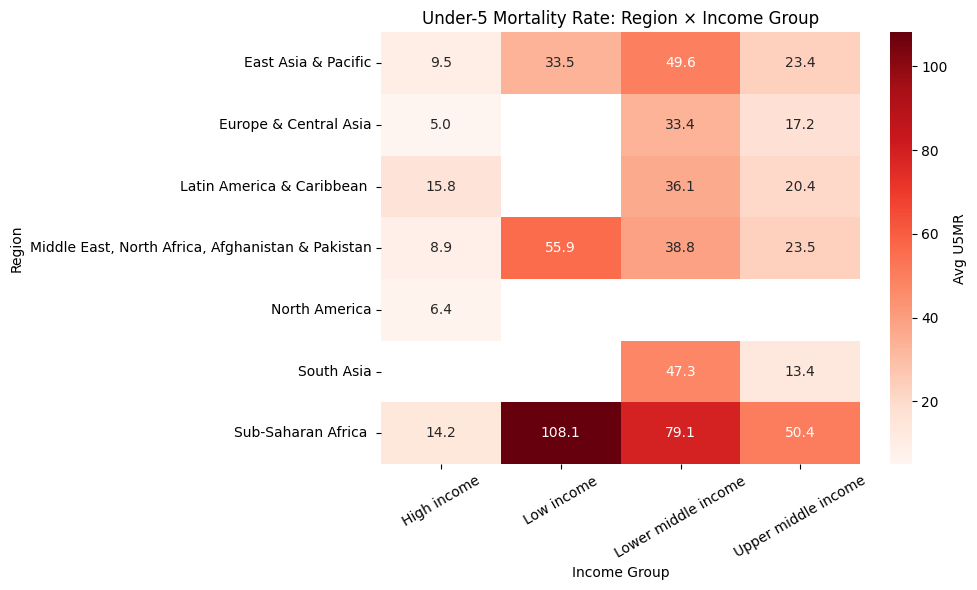

In [13]:
import seaborn as sns

heatmap_data = mortality_under_5.pivot_table(
    index='regions', columns='income_level', values='per_1000', aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Avg U5MR'})
plt.title('Under-5 Mortality Rate: Region × Income Group')
plt.xlabel('Income Group')
plt.xticks(rotation=30)
plt.ylabel('Region')
plt.tight_layout()
#plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 4'}/heatmap_region_income.png', dpi=200)
plt.show()

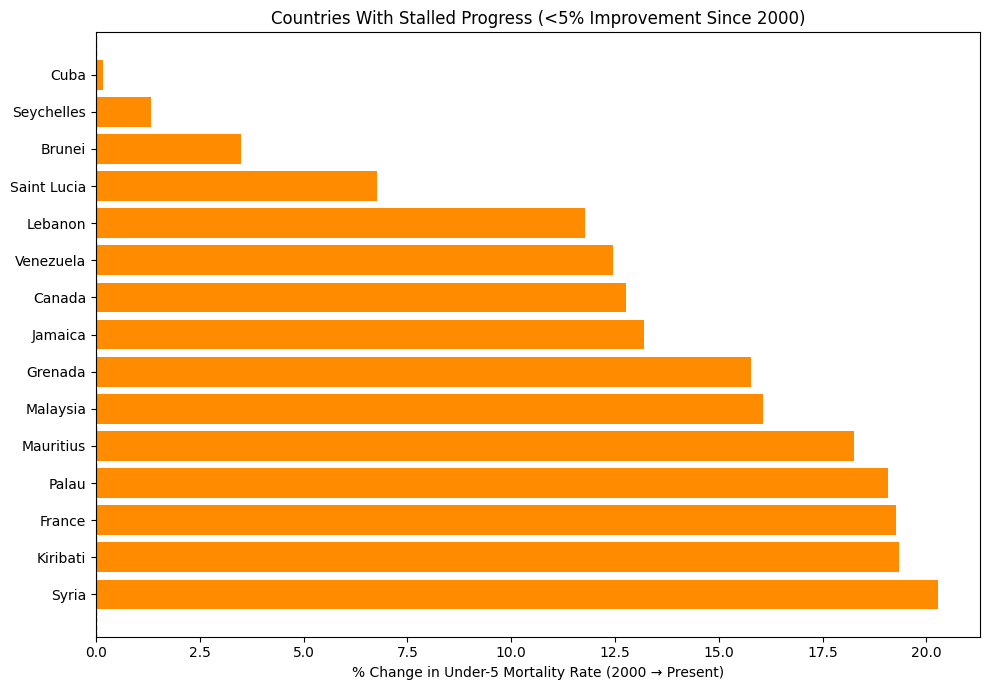

In [14]:
stalled_sorted = change.sort_values('pct_change', ascending=True).head(15)  # worst-stalled at top

plt.figure(figsize=(10, 7))
plt.barh(stalled_sorted['entity'], stalled_sorted['pct_change'], color='darkorange')
plt.xlabel('% Change in Under-5 Mortality Rate (2000 → Present)')
plt.title('Countries With Stalled Progress (<5% Improvement Since 2000)')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.tight_layout()
#plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 4'}/stalled_countries_barh.png', dpi=200)
plt.show()